In [1]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *


In [264]:
g_linspace = array([1.0001,1.1,1.2,1.3,2,3,4,5])
L = 100
k = kb.k_vals(L)
Us = [kb.U(k,gi) for gi in g_linspace]

ns = np.arange(2,13)


In [265]:
rs = np.arange(1,20)
data = []
corrs = []
for g, U in zip(g_linspace, Us):
    dat = np.array([kb.P_n(ni, U, k)  for ni in tqdm(ns)])
    data.append(dat)
    corr = np.array([kb.sigma_general([0,i],U,k) for i in rs])
    corrs.append(corr)
    print(g)

  0%|          | 0/11 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 11/11 [00:01<00:00,  8.55it/s]


1.0001


100%|██████████| 11/11 [00:01<00:00,  8.78it/s]


1.1


100%|██████████| 11/11 [00:01<00:00,  8.73it/s]


...

3.0


100%|██████████| 11/11 [00:01<00:00,  8.66it/s]


4.0


100%|██████████| 11/11 [00:01<00:00,  8.79it/s]


5.0


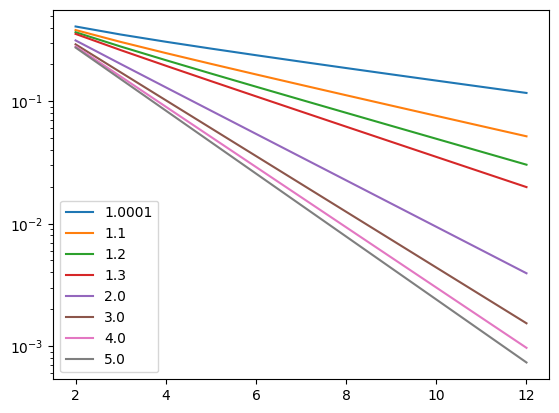

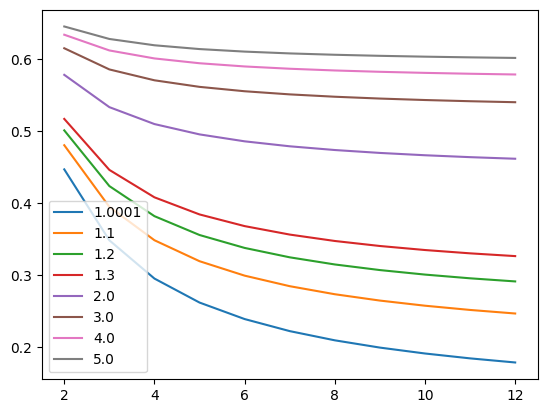

In [266]:
for dat,g in zip(data,g_linspace):
    plot(ns,dat,label=g)
yscale("log")
legend()
show()

for dat,g in zip(data,g_linspace):
    plot(ns,-log(dat)/ns,label=g)

legend()


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_81444/863732126.py:13: RuntimeWarning: invalid value encountered in log
  plot(abs(1-g_linspace),log(2)-1/2/abs(1-g_linspace)+log(1-g_linspace))


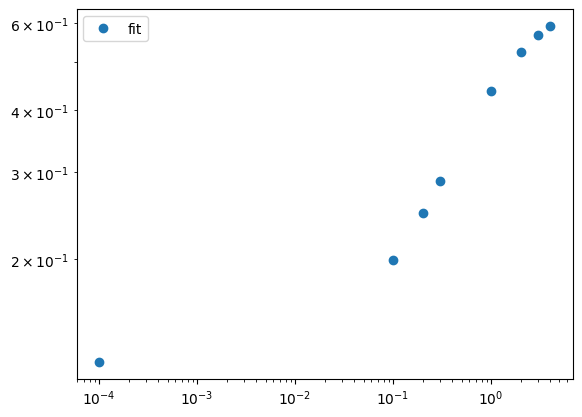

In [270]:
slopes = []
for dat, g in zip(data, g_linspace):
    y = -np.log(dat)
    m, b = np.polyfit(ns, y, 1)   # m = 1/xi
    slopes.append(m)
slopes = array(slopes)
plt.figure()
plt.plot(abs(1-g_linspace), slopes, 'o', label='fit')


#loglog()

plot(abs(1-g_linspace),log(2)-1/2/abs(1-g_linspace)+log(1-g_linspace))
loglog()
plt.legend()
#lt.hlines(log(2),g_linspace[0],g_linspace[-1])


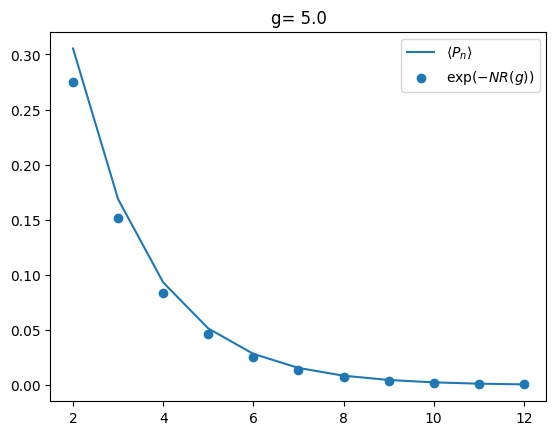

In [254]:
j = -1
g0 = g_linspace[j]
d = data[j]

plot(ns,exp(-ns*(log(2)-1/2/g0)),label=r"$\langle P_n \rangle$")
scatter(ns,d,label=r"$\exp(-N R(g) ) $")
title(f"g= {g0}")
legend()


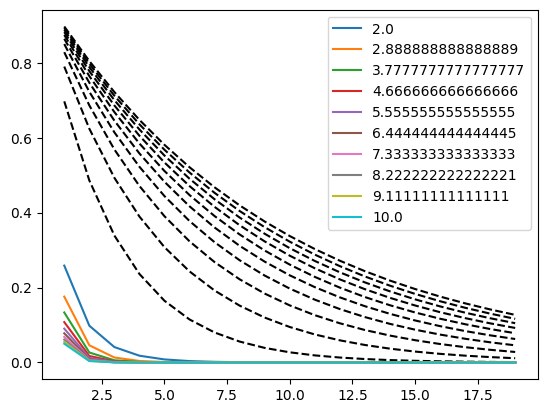

In [123]:
for c,g in zip(corrs,g_linspace):
    plot(rs,c,label=g)
    plot(rs,exp(-rs/np.abs(log(g))/4),"--k")
#yscale("log")
legend()

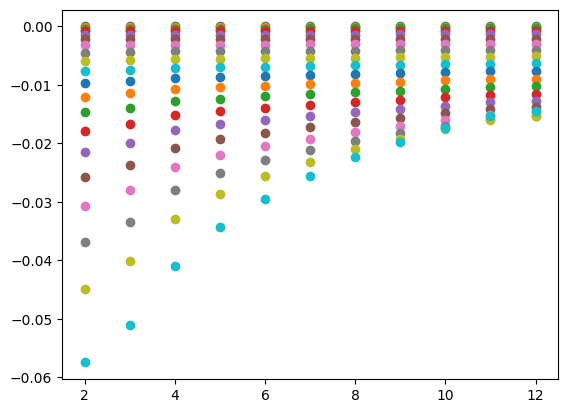

In [71]:
for p,g in zip(grads,g_linspace):
    #plot(ns,-log(p))
    #p = -log(p)
    d1 = np.gradient(p,ns)
    d2 = np.gradient(d1,ns)
    scatter(ns,d1)


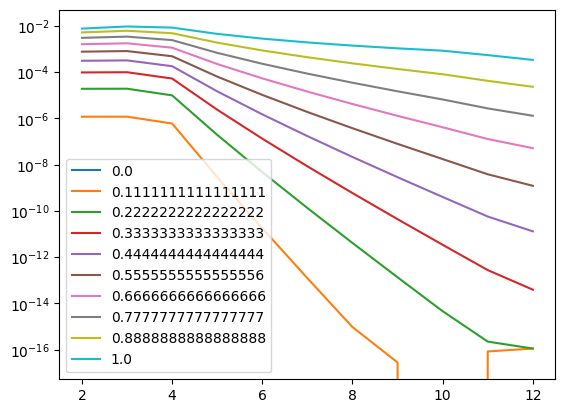

In [31]:
for gr,g in zip(grads,g_linspace):
    plot(ns,np.abs(array(gr)),label=g)
legend()
yscale("log")

In [168]:
import equilibrium_critical_correlations as eq
import equilibrium_z_projectors as ez 
from tqdm import tqdm

ns = np.arange(1,13)

100%|██████████| 12/12 [00:00<00:00, 127.41it/s]
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0.5, 1.0, 'g=1')

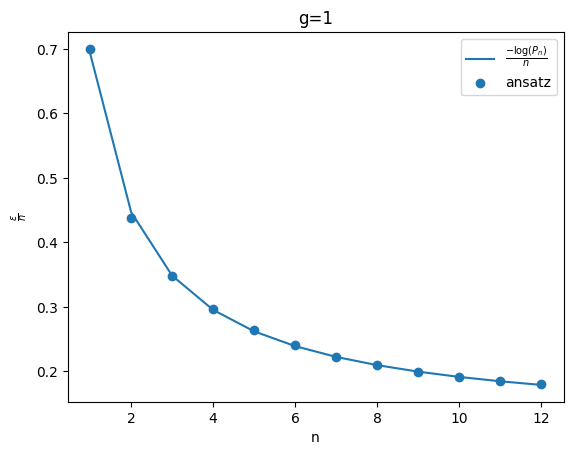

In [207]:
#P =array([-log(ez.P_n(ni))/ni for  ni in tqdm(ns)])

#plot(ns,P)
E =array([-log(eq.P_n(ni)) for  ni in tqdm(ns)])



plot(ns,E/ns,label=r"$\frac{-\log(P_n)}{n}$")
scatter(ns,(ns*a1+ns**2*a2+b0*log(ns)+b1*ns*log(ns))/ns,label=r"ansatz")
xlabel("n")
legend()
ylabel(r"$\frac{\epsilon}{n}$")
title("g=1")

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


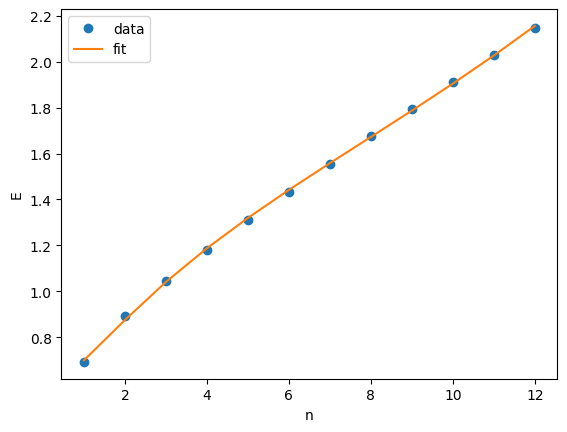

In [197]:
import numpy as np
import matplotlib.pyplot as plt

# data
ns = np.asarray(ns)
E  = np.asarray(E)

# optional: restrict to large-n window
# mask = ns >= n_min
# ns_fit, E_fit = ns[mask], E[mask]
ns_fit, E_fit = ns, E

# design matrix
X = np.column_stack([ns_fit**2, ns_fit, np.log(ns_fit),ns_fit*log(ns_fit)])

# least-squares fit
coeffs, residuals, rank, s = np.linalg.lstsq(X, E_fit, rcond=None)
a2, a1, b0,b1 = coeffs

# fitted curve
E_fit_curve = a2*ns**2 + a1*ns + b0*np.log(ns)+b1*ns*np.log(ns)

# plot
plt.figure()
plt.plot(ns, E, "o", label="data")
plt.plot(ns, E_fit_curve, "-", label="fit")
plt.xlabel("n")
plt.ylabel("E")
plt.legend()
plt.show()
